#### Import packages

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import csv
from scipy import stats
import numpy as np
import os
import requests
from io import StringIO
from sklearn.cluster import KMeans
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from scipy.stats import spearmanr, pearsonr, linregress, shapiro, levene, ttest_ind, mannwhitneyu
%pip install statsmodels
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

Note: you may need to restart the kernel to use updated packages.


#### Import csv

In [3]:
df_data = pd.read_csv('../dataset/behavioural_data/processed_experiment_data.csv')

df_gambles = pd.read_csv('../application/src/static/gambles/gambles.csv')

df_random_slopes = pd.read_csv('random_and_participant_T_frac_slopes.csv')

df_final_questionnaire = pd.read_csv('../dataset/questionnaire_answers/final_questionnaire_answers.csv')

df_clean = df_data[(df_data['Counter'] == 0) & (df_data['FullScreenExited'] == 0)]

df_simple_slopes_analysis = pd.read_csv('simple_slopes_analysis.csv')

### Visualize gambles attributes

findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
fin

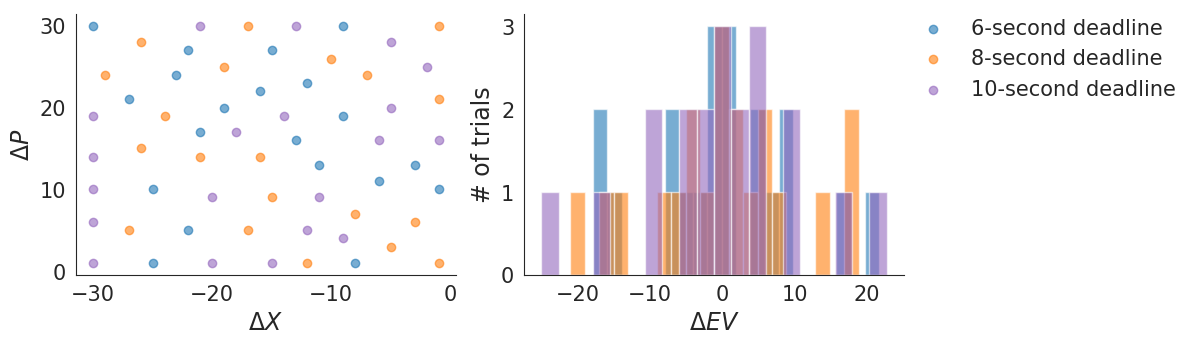

In [3]:
# --- Seaborn style ---
sns.set_style("white")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Liberation Sans"],
})

fontsize = 17

gambles_deadline_6 = df_gambles[df_gambles['Deadline']==6]
gambles_deadline_8 = df_gambles[df_gambles['Deadline']==8]
gambles_deadline_10 = df_gambles[df_gambles['Deadline']==10]

# --- Create figure ---
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=False)

# --- Define colors from Matplotlib's default palette ---
colors = ["C0", "C1", "C4"]

# --- Scatter plot (left panel) ---
axes[0].scatter(gambles_deadline_6['dX'], gambles_deadline_6['dP'], 
                color=colors[0], alpha=0.6, label='6-second deadline')
axes[0].scatter(gambles_deadline_8['dX'], gambles_deadline_8['dP'], 
                color=colors[1], alpha=0.6, label='8-second deadline')
axes[0].scatter(gambles_deadline_10['dX'], gambles_deadline_10['dP'], 
                color=colors[2], alpha=0.6, label='10-second deadline')
#axes[0].set_xlabel("dX", fontsize=fontsize)
#axes[0].set_ylabel("dP", fontsize=fontsize)

# --- Histogram (right panel) ---
axes[1].hist(gambles_deadline_6['dEV'], color=colors[0], alpha=0.6, label='6-second deadline',bins = 20)
axes[1].hist(gambles_deadline_8['dEV'], color=colors[1], alpha=0.6, label='8-second deadline',bins = 20)
axes[1].hist(gambles_deadline_10['dEV'], color=colors[2], alpha=0.6, label='10-second deadline',bins = 20)
#axes[1].set_xlabel("dEV", fontsize=fontsize)
axes[1].set_ylabel("# of trials", fontsize=fontsize)
axes[1].yaxis.set_major_locator(MaxNLocator(integer=True))

axes[0].set_xlabel(r"$\Delta X$", fontsize=fontsize)
axes[0].set_ylabel(r"$\Delta P$", fontsize=fontsize)

axes[1].set_xlabel(r"$\Delta EV$", fontsize=fontsize)
# --- Shared legend to the right ---
# handles, labels from any axis (they’re the same)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=15, frameon=False)

# --- Despine (remove upper/right borders) ---
for ax in axes:
    sns.despine(ax=ax, top=True, right=True)
    ax.tick_params(axis='both', which='major', labelsize=15)


plt.tight_layout(rect=[0, 0, 0.77, 1])  # leave space on right for legend

plt.savefig("gambles_attributes.tif",
              format="tiff",
                dpi=600,
            bbox_inches="tight",
            pad_inches=0.25,
            pil_kwargs={"compression": "tiff_lzw"},
            transparent=True)


plt.show()

### Visualize central-tendency bias

findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following fa

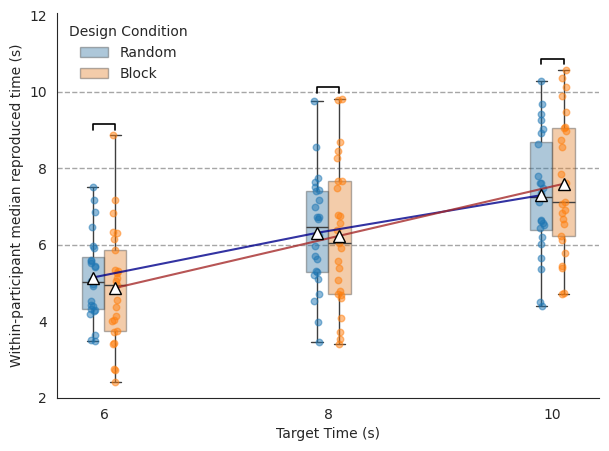

In [7]:
# 1. Prepare data
participant_medians = (
    df_clean.groupby(
        ["ParticipantID", "GambleDeadline", "DeadlinePresentationOrder"],
        as_index=False
    )["ReproducedTime"].median()
)

# Calculate means for connecting lines
group_means = (
    participant_medians
    .groupby(["GambleDeadline", "DeadlinePresentationOrder"])["ReproducedTime"]
    .mean()
    .reset_index()
)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

# Settings
BOX_WIDTH = 0.2
HUE_OFFSET = BOX_WIDTH / 4
JITTER_WIDTH = BOX_WIDTH / 16

deadline_order = [6, 8, 10]
hue_order = ["Random", "Block"]

# Define matching colors
palette = {
    "Random": "C0",
    "Block": "C1"
}

# Optional: fixed random seed for reproducible jitter
rng = np.random.default_rng(123)

# 2. Plot boxplots
ax = sns.boxplot(
    data=participant_medians,
    x="GambleDeadline",
    y="ReproducedTime",
    hue="DeadlinePresentationOrder",
    order=deadline_order,
    hue_order=hue_order,
    palette=palette,
    width=BOX_WIDTH,
    showfliers=False,
    boxprops=dict(alpha=0.4),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 8,
        "zorder": 10
    }
)

# 3. Manually add colored dots aligned to the boxplot centers
deadline_to_x = {deadline: i for i, deadline in enumerate(deadline_order)}
condition_to_offset = {
    "Random": -HUE_OFFSET,
    "Block": HUE_OFFSET
}

for condition in hue_order:
    for deadline in deadline_order:
        subset = participant_medians[
            (participant_medians["DeadlinePresentationOrder"] == condition) &
            (participant_medians["GambleDeadline"] == deadline)
        ]

        x_center = deadline_to_x[deadline] + condition_to_offset[condition]
        x_jittered = x_center + rng.uniform(
            low=-JITTER_WIDTH,
            high=JITTER_WIDTH,
            size=len(subset)
        )

        ax.scatter(
            x_jittered,
            subset["ReproducedTime"],
            alpha=0.5,
            s=22,
            zorder=8,
            color=palette[condition]
        )

# 4. Add lines connecting the means
x_base = np.array([0, 1, 2])
x_coords_random = x_base - HUE_OFFSET
x_coords_block = x_base + HUE_OFFSET

y_means_random = (
    group_means[group_means["DeadlinePresentationOrder"] == "Random"]
    .set_index("GambleDeadline")
    .loc[deadline_order, "ReproducedTime"]
    .values
)

y_means_block = (
    group_means[group_means["DeadlinePresentationOrder"] == "Block"]
    .set_index("GambleDeadline")
    .loc[deadline_order, "ReproducedTime"]
    .values
)

ax.plot(
    x_coords_random,
    y_means_random,
    color="darkblue",
    linestyle="-",
    linewidth=1.5,
    alpha=0.8,
    zorder=9
)

ax.plot(
    x_coords_block,
    y_means_block,
    color="brown",
    linestyle="-",
    linewidth=1.5,
    alpha=0.8,
    zorder=9
)

# 5. Add comparison brackets
bracket_padding = 0.3
tick_height = 0.15

for i, deadline in enumerate(deadline_order):
    group_max = participant_medians[
        participant_medians["GambleDeadline"] == deadline
    ]["ReproducedTime"].max()

    x1, x2 = i - HUE_OFFSET, i + HUE_OFFSET
    y_base = group_max + bracket_padding

    ax.plot(
        [x1, x1, x2, x2],
        [y_base - tick_height, y_base, y_base, y_base - tick_height],
        lw=1.2,
        color="black"
    )

# 6. Add horizontal reference lines
for y in [6, 8, 10]:
    ax.axhline(
        y=y,
        color="grey",
        linestyle="--",
        linewidth=1,
        alpha=0.7,
        zorder=0
    )

# 7. Final styling
sns.despine()

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[:2],
    labels[:2],
    title="Design Condition",
    frameon=False,
    loc="upper left"
)

plt.xlabel("Target Time (s)")
plt.ylabel("Within-participant median reproduced time (s)")
plt.ylim(
    bottom=2,
    top=participant_medians["ReproducedTime"].max() + 1.5
)

# 8. Save
plt.savefig(
    "reproduced_times_connected.tif",
    format="tiff",
    dpi=600,
    bbox_inches="tight",
    pil_kwargs={"compression": "tiff_lzw"}
)

plt.show()

In [9]:
normality_results = []

# Define the groups as they appear in your plot
deadlines = [6, 8, 10]
orders = ["Random", "Block"]

for deadline in deadlines:
    for order in orders:
        # Filter data for the specific group
        group_data = participant_medians[
            (participant_medians["GambleDeadline"] == deadline) & 
            (participant_medians["DeadlinePresentationOrder"] == order)
        ]["ReproducedTime"]
        
        # Check if we have enough data points (Shapiro-Wilk requires N > 3)
        if len(group_data) >= 3:
            stat, p_val = stats.shapiro(group_data)
            
            normality_results.append({
                "GambleDeadline": deadline,
                "Order": order,
                "Sample_Size": len(group_data),
                "W_Statistic": round(stat, 4),
                "p_value": round(p_val, 4),
                "is_normal": p_val > 0.05  # True if p > .05
            })

# Convert to DataFrame for a clean table output
normality_df = pd.DataFrame(normality_results)
print(normality_df)

   GambleDeadline   Order  Sample_Size  W_Statistic  p_value  is_normal
0               6  Random           24       0.9554   0.3525       True
1               6   Block           25       0.9696   0.6342       True
2               8  Random           24       0.9850   0.9678       True
3               8   Block           25       0.9600   0.4150       True
4              10  Random           24       0.9716   0.7061       True
5              10   Block           25       0.9532   0.2960       True


In [10]:


target_times = [6, 8, 10]

for time in target_times:
    random_group = participant_medians[
        (participant_medians["GambleDeadline"] == time) & 
        (participant_medians["DeadlinePresentationOrder"] == "Random")
    ]["ReproducedTime"]
    
    block_group = participant_medians[
        (participant_medians["GambleDeadline"] == time) & 
        (participant_medians["DeadlinePresentationOrder"] == "Block")
    ]["ReproducedTime"]
    
    # equal_var=False makes this a Welch's T-Test
    t_stat, p_val = stats.ttest_ind(random_group, block_group, equal_var=False)
    
    print(f"Target Time {time}s (N_Random={len(random_group)}, N_Block={len(block_group)}):")
    print(f"  p-value: {p_val:.4f}")

Target Time 6s (N_Random=24, N_Block=25):
  p-value: 0.4801
Target Time 8s (N_Random=24, N_Block=25):
  p-value: 0.8737
Target Time 10s (N_Random=24, N_Block=25):
  p-value: 0.5431


### Other analysis

## Completion time, and demographic data

In [5]:
completion_study_times = df_final_questionnaire['TotalObjectiveStudyTime'] / 60

print(f"Median completion time (minutes): {completion_study_times.median():.2f}")

Median completion time (minutes): 41.93


In [22]:
df_non_counters = df_data[df_data['Counter'] == 0]

print("Minimum age:", df_non_counters["Age"].min())
print("Maximum age:", df_non_counters["Age"].max())
print("Standard deviation of age:", df_non_counters["Age"].std())
print("Average age:", df_non_counters["Age"].mean())
print("Median age:", df_non_counters["Age"].median())
print("Number of participants:", df_non_counters["ParticipantID"].nunique())
print("Number of female participants:", df_non_counters[df_non_counters['Sex'] == 'Female']["ParticipantID"].nunique())

df_non_counters_block = df_non_counters[df_non_counters['DeadlinePresentationOrder'] == 'Block']
df_non_counters_random = df_non_counters[df_non_counters['DeadlinePresentationOrder'] == 'Random']

print("Number of participants in block order:", df_non_counters_block["ParticipantID"].nunique())
print("Number of participants in random order:", df_non_counters_random["ParticipantID"].nunique())


Minimum age: 21
Maximum age: 69
Standard deviation of age: 10.610367746668274
Average age: 42.10511562718991
Median age: 41.0
Number of participants: 49
Number of female participants: 23
Number of participants in block order: 25
Number of participants in random order: 24


#### Risk attitude and decision speed

Pearson's r = 0.419, p = 0.00276


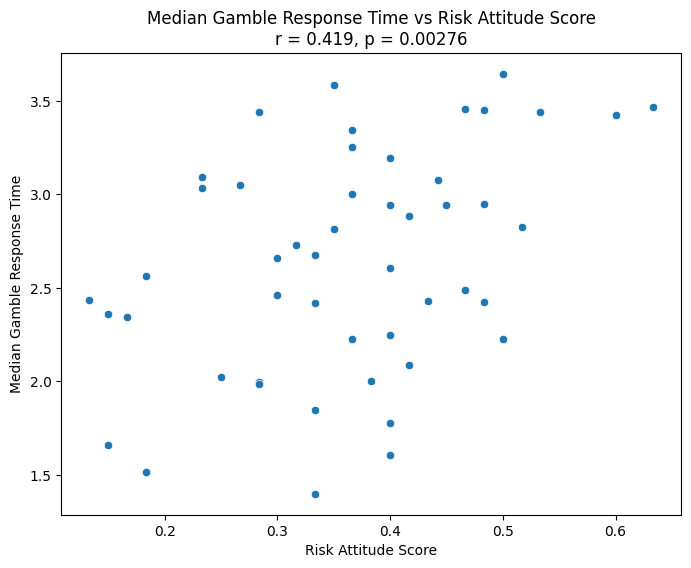

Mean RiskAttitudeScore = 0.364
SD RiskAttitudeScore = 0.117
Median RiskAttitudeScore = 0.367


In [6]:
df_plot = (
    df_clean
    .groupby("ParticipantID", as_index=False)
    .agg(
        MedianGambleResponseTime=("GambleResponseTime", "median"),
        RiskAttitudeScore=("RiskAttitudeScore", "first")
    )
)

r, p = pearsonr(
    df_plot["RiskAttitudeScore"],
    df_plot["MedianGambleResponseTime"]
)

print(f"Pearson's r = {r:.3f}, p = {p:.3g}")

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_plot,
    x="RiskAttitudeScore",
    y="MedianGambleResponseTime"
)

plt.xlabel("Risk Attitude Score")
plt.ylabel("Median Gamble Response Time")
plt.title(f"Median Gamble Response Time vs Risk Attitude Score\nr = {r:.3f}, p = {p:.3g}")
plt.show()
risk_mean = df_plot["RiskAttitudeScore"].mean()
risk_sd = df_plot["RiskAttitudeScore"].std()
risk_median = df_plot["RiskAttitudeScore"].median()


print(f"Mean RiskAttitudeScore = {risk_mean:.3f}")
print(f"SD RiskAttitudeScore = {risk_sd:.3f}")
print(f"Median RiskAttitudeScore = {risk_median:.3f}")




C:\Users\algar\AppData\Local\Temp\ipykernel_1512\4185224445.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["DurationJudgmentRatio"] = (
C:\Users\algar\AppData\Local\Temp\ipykernel_1512\4185224445.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["ThinkingFraction"] = (
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Lib

Pearson's r = 0.054, p = 0.711


findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following fa

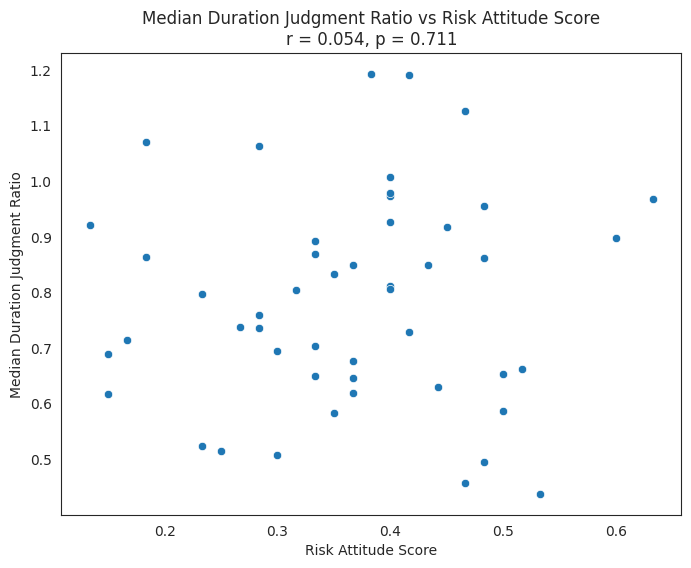

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

df_clean["DurationJudgmentRatio"] = (
    df_clean["ReproducedTime"] / df_clean["GambleDeadline"]
)

df_clean["ThinkingFraction"] = (
    df_clean["GambleResponseTime"] / df_clean["GambleDeadline"]
)

df_plot = (
    df_clean
    .groupby("ParticipantID", as_index=False)
    .agg(
        MedianDurationJudgmentRatio=("DurationJudgmentRatio", "median"),
        RiskAttitudeScore=("RiskAttitudeScore", "first")
    )
)

r, p = pearsonr(
    df_plot["RiskAttitudeScore"],
    df_plot["MedianDurationJudgmentRatio"]
)

print(f"Pearson's r = {r:.3f}, p = {p:.3g}")

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_plot,
    x="RiskAttitudeScore",
    y="MedianDurationJudgmentRatio"
)

plt.xlabel("Risk Attitude Score")
plt.ylabel("Median Duration Judgment Ratio")
plt.title(f"Median Duration Judgment Ratio vs Risk Attitude Score\nr = {r:.3f}, p = {p:.3g}")
plt.show()


findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following fa

Pearson's r = 0.453, p = 0.00109


findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans


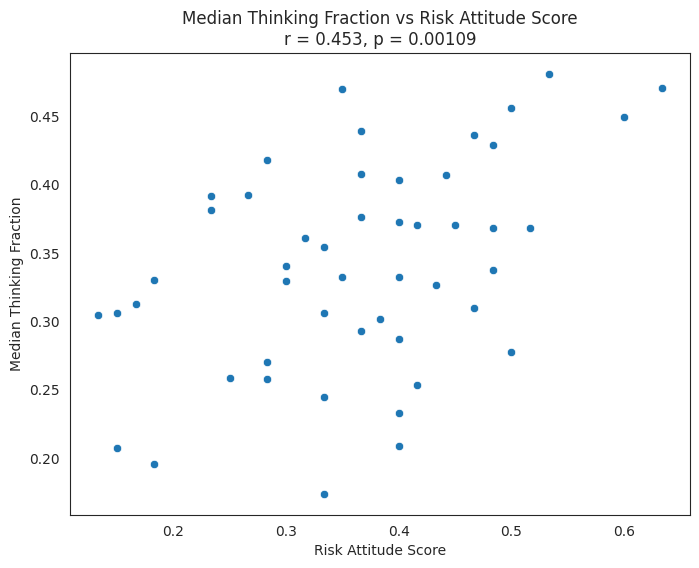

In [14]:
df_plot = (
    df_clean
    .groupby("ParticipantID", as_index=False)
    .agg(
        MedianThinkingFraction=("ThinkingFraction", "median"),
        RiskAttitudeScore=("RiskAttitudeScore", "first")
    )
)


r, p = pearsonr(
    df_plot["RiskAttitudeScore"],
    df_plot["MedianThinkingFraction"]
)

print(f"Pearson's r = {r:.3f}, p = {p:.3g}")

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_plot,
    x="RiskAttitudeScore",
    y="MedianThinkingFraction"
)

plt.xlabel("Risk Attitude Score")
plt.ylabel("Median Thinking Fraction")
plt.title(f"Median Thinking Fraction vs Risk Attitude Score\nr = {r:.3f}, p = {p:.3g}")
plt.show()

In [14]:
df_clean.columns

Index(['ParticipantID', 'DeadlinePresentationOrder', 'BlockNumber',
       'ExperimentRoundNumber', 'ExperimentGambleNumber', 'LotteryLeft',
       'LotteryRight', 'GambleChoice', 'GambleResponseTime',
       'GambleSecondaryChoices', 'GambleSecondaryChoicesTimes',
       'GambleDeadline', 'FullScreenExited', 'ReproducedTime',
       'MissedDeadline', 'SubjectiveDifficulty',
       'ResponseTimeSubjectiveDifficulty',
       'ResponseTimeSubmitAnswersQuestionnaire', 'Counter', 'Age', 'Sex',
       'SubjectiveDifficulty3Lev', 'lot_0_val', 'lot_0_prob', 'lot_0_ev',
       'lot_1_val', 'lot_1_prob', 'lot_1_ev', 'dX', 'dP', 'dEV', 'dEV_bin',
       'RiskyChoice', 'BlockRoundNumber', 'AbsoluteError', 'RiskAttitudeScore',
       'DurationJudgmentRatio'],
      dtype='object')

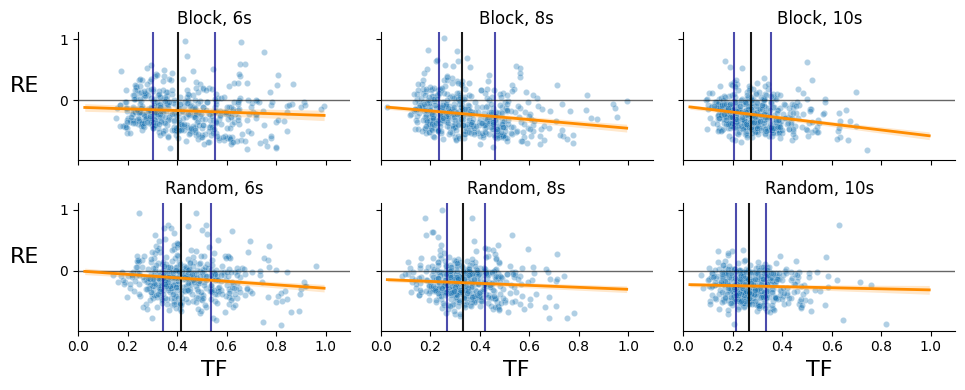

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_clean = df_clean.copy()
df_clean["Delta"] = df_clean["ReproducedTime"] - df_clean["GambleDeadline"]
df_clean["RE"] = (df_clean["ReproducedTime"] - df_clean["GambleDeadline"]) / df_clean["GambleDeadline"]
df_clean["TF"] = df_clean["GambleResponseTime"] / df_clean["GambleDeadline"]

plot_df = df_clean[
    (df_clean["DeadlinePresentationOrder"].isin(["Random", "Block"])) &
    (df_clean["GambleDeadline"].isin([6, 8, 10]))
].copy()

pred_df = df_simple_slopes_analysis.copy()
if "TF" not in pred_df.columns:
    tf_mean = df_clean["TF"].mean()
    pred_df["TF"] = pred_df["T_frac_c"] + tf_mean

fig, axes = plt.subplots(2, 3, figsize=(10, 4), sharex=True, sharey=True)

deadlines = [6, 8, 10]
conditions = ["Block", "Random"]

for i, condition in enumerate(conditions):
    for j, deadline in enumerate(deadlines):
        ax = axes[i, j]

        target_time = f"{deadline} s"

        subset = plot_df[
            (plot_df["GambleDeadline"] == deadline) &
            (plot_df["DeadlinePresentationOrder"] == condition)
        ].dropna(subset=["TF", "Delta", "ParticipantID"])

        pred_subset = pred_df[
            (pred_df["TargetTime"] == target_time) &
            (pred_df["Condition"] == condition)
        ].sort_values("TF")

        sns.scatterplot(
            data=subset,
            x="TF",
            #y="Delta",
            y="RE",
            alpha=0.35,
            s=20,
            ax=ax
        )

        q25 = subset["TF"].quantile(0.25)
        median = subset["TF"].median()
        q75 = subset["TF"].quantile(0.75)

        ax.axvline(q25, color="darkblue", linestyle="-", linewidth=1.5, alpha=0.7)
        ax.axvline(median, color="black", linestyle="-", linewidth=1.5, alpha=0.9)
        ax.axvline(q75, color="darkblue", linestyle="-", linewidth=1.5, alpha=0.7)

        ax.axhline(0, color="black", linestyle="-", linewidth=1, alpha=0.6)

        if len(pred_subset) > 0:
            ax.plot(
                pred_subset["TF"],
                #pred_subset["emmean"],
                pred_subset["emmean"]/deadline,
                color="darkorange",
                linewidth=2
            )

            ax.fill_between(
                pred_subset["TF"],
                pred_subset["emmean"]/deadline - pred_subset["SE"]/deadline,
                pred_subset["emmean"]/deadline + pred_subset["SE"]/deadline,
                color="darkorange",
                alpha=0.20,
                linewidth=0
            )

        else:
            print(f"No model predictions found for {condition}, {deadline}s")

        ax.set_xlim(0, 1.1)

        ax.set_title(f"{condition}, {deadline}s", fontsize=12)
        ax.set_xlabel("TF" if i == 1 else "", fontsize=16)
        ax.set_ylabel(
            #r"$\Delta t$ (s)" if j == 0 else "",
            r"RE" if j == 0 else "",
            rotation=0,
            labelpad=25,
            fontsize=16
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(top=False, right=False)

plt.tight_layout()

fig.savefig(
    "tf_relative_error_by_condition_deadline.svg",
    format="svg",
    bbox_inches="tight"
)
plt.show()


## Code for section: Task design affects between-participant variability in Thinking Fraction

In [21]:
df_iqr = df_clean.copy()

df_iqr["TF"] = df_iqr["GambleResponseTime"] / df_iqr["GambleDeadline"]

df_iqr = df_iqr[
    (df_iqr["DeadlinePresentationOrder"].isin(["Block", "Random"])) &
    (df_iqr["GambleDeadline"].isin([6, 8, 10]))
].copy()

participant_iqr = (
    df_iqr
    .dropna(subset=[
        "ParticipantID",
        "DeadlinePresentationOrder",
        "GambleDeadline",
        "TF"
    ])
    .groupby([
        "ParticipantID",
        "DeadlinePresentationOrder",
        "GambleDeadline"
    ])
    .agg(
        TF_iqr=("TF", lambda x: x.quantile(0.75) - x.quantile(0.25)),
        n_trials=("TF", "count")
    )
    .reset_index()
)


summary = (
    participant_iqr
    .groupby(["GambleDeadline", "DeadlinePresentationOrder"])
    .agg(
        n=("TF_iqr", "count"),
        median_TF_iqr=("TF_iqr", "median"),
        mean_TF_iqr=("TF_iqr", "mean"),
        sd_TF_iqr=("TF_iqr", "std"),
        q25_TF_iqr=("TF_iqr", lambda x: x.quantile(0.25)),
        q75_TF_iqr=("TF_iqr", lambda x: x.quantile(0.75))
    )
    .reset_index()
)

print(summary)

   GambleDeadline DeadlinePresentationOrder   n  median_TF_iqr  mean_TF_iqr  \
0               6                     Block  25       0.135588     0.151899   
1               6                    Random  24       0.133833     0.147847   
2               8                     Block  25       0.134381     0.144561   
3               8                    Random  24       0.123306     0.128525   
4              10                     Block  25       0.095332     0.107169   
5              10                    Random  24       0.096942     0.104780   

   sd_TF_iqr  q25_TF_iqr  q75_TF_iqr  
0   0.074254    0.096492    0.197621  
1   0.065293    0.111615    0.173098  
2   0.078155    0.077972    0.208944  
3   0.044352    0.092123    0.162052  
4   0.051219    0.067585    0.140335  
5   0.039543    0.082529    0.115479  


#### Check if distributions are normal

In [22]:
for deadline in [6, 8, 10]:
    for condition in ["Block", "Random"]:
        vals = participant_iqr[
            (participant_iqr["GambleDeadline"] == deadline) &
            (participant_iqr["DeadlinePresentationOrder"] == condition)
        ]["TF_iqr"].dropna()

        stat, p = shapiro(vals)

        print(
            f"IQR, {condition}, {deadline}s: "
            f"W = {stat:.3f}, p = {p:.4g}"
        )

IQR, Block, 6s: W = 0.907, p = 0.02593
IQR, Random, 6s: W = 0.939, p = 0.1521
IQR, Block, 8s: W = 0.927, p = 0.07603
IQR, Random, 8s: W = 0.971, p = 0.6956
IQR, Block, 10s: W = 0.914, p = 0.03818
IQR, Random, 10s: W = 0.900, p = 0.02146


#### Perform Mann-Whitney U tests

In [23]:
results = []

for deadline in [6, 8, 10]:
    block_iqr = participant_iqr[
        (participant_iqr["GambleDeadline"] == deadline) &
        (participant_iqr["DeadlinePresentationOrder"] == "Block")
    ]["TF_iqr"].dropna()

    random_iqr = participant_iqr[
        (participant_iqr["GambleDeadline"] == deadline) &
        (participant_iqr["DeadlinePresentationOrder"] == "Random")
    ]["TF_iqr"].dropna()

    stat, p = mannwhitneyu(
        block_iqr,
        random_iqr,
        alternative="two-sided"
    )

    results.append({
        "GambleDeadline": deadline,
        "n_block": len(block_iqr),
        "n_random": len(random_iqr),
        "median_block": block_iqr.median(),
        "median_random": random_iqr.median(),
        "U": stat,
        "p": p
    })

results_df = pd.DataFrame(results)

reject, p_adj, _, _ = multipletests(
    results_df["p"],
    method="holm"
)

results_df["p_holm"] = p_adj
results_df["significant_holm"] = reject

print(results_df)

   GambleDeadline  n_block  n_random  median_block  median_random      U  \
0               6       25        24      0.135588       0.133833  296.0   
1               8       25        24      0.134381       0.123306  312.0   
2              10       25        24      0.095332       0.096942  289.0   

          p  p_holm  significant_holm  
0  0.944194     1.0             False  
1  0.818092     1.0             False  
2  0.833668     1.0             False  


#### Perform t-test

In [26]:
ttest_results = []

for deadline in [6, 8, 10]:
    block_iqr = participant_iqr[
        (participant_iqr["GambleDeadline"] == deadline) &
        (participant_iqr["DeadlinePresentationOrder"] == "Block")
    ]["TF_iqr"].dropna()

    random_iqr = participant_iqr[
        (participant_iqr["GambleDeadline"] == deadline) &
        (participant_iqr["DeadlinePresentationOrder"] == "Random")
    ]["TF_iqr"].dropna()

    stat, p = ttest_ind(
        block_iqr,
        random_iqr,
        equal_var=False
    )

    ttest_results.append({
        "GambleDeadline": deadline,
        "t": stat,
        "p": p
    })

ttest_results_df = pd.DataFrame(ttest_results)

reject, p_holm, _, _ = multipletests(
    ttest_results_df["p"],
    method="holm"
)

ttest_results_df["p_holm"] = p_holm
ttest_results_df["significant_holm"] = reject

print(ttest_results_df)

   GambleDeadline         t         p  p_holm  significant_holm
0               6  0.203103  0.839938     1.0             False
1               8  0.887784  0.380198     1.0             False
2              10  0.183221  0.855448     1.0             False


#### Perform Levene test

In [27]:

df_med = df_clean.copy()

df_med["TF"] = df_med["GambleResponseTime"] / df_med["GambleDeadline"]

df_med = df_med[
    (df_med["DeadlinePresentationOrder"].isin(["Block", "Random"])) &
    (df_med["GambleDeadline"].isin([6, 8, 10]))
].copy()

participant_median_tf = (
    df_med
    .dropna(subset=[
        "ParticipantID",
        "DeadlinePresentationOrder",
        "GambleDeadline",
        "TF"
    ])
    .groupby([
        "ParticipantID",
        "DeadlinePresentationOrder",
        "GambleDeadline"
    ])
    .agg(
        median_TF=("TF", "median"),
        n_trials=("TF", "count")
    )
    .reset_index()
)


summary_median_tf = (
    participant_median_tf
    .groupby(["GambleDeadline", "DeadlinePresentationOrder"])
    .agg(
        n=("median_TF", "count"),
        median_of_median_TF=("median_TF", "median"),
        mean_median_TF=("median_TF", "mean"),
        sd_median_TF=("median_TF", "std"),
        q25_median_TF=("median_TF", lambda x: x.quantile(0.25)),
        q75_median_TF=("median_TF", lambda x: x.quantile(0.75))
    )
    .reset_index()
)

print(summary_median_tf)

results = []

for deadline in [6, 8, 10]:
    block_medians = participant_median_tf[
        (participant_median_tf["GambleDeadline"] == deadline) &
        (participant_median_tf["DeadlinePresentationOrder"] == "Block")
    ]["median_TF"].dropna()

    random_medians = participant_median_tf[
        (participant_median_tf["GambleDeadline"] == deadline) &
        (participant_median_tf["DeadlinePresentationOrder"] == "Random")
    ]["median_TF"].dropna()

    stat, p = levene(
        block_medians,
        random_medians,
        center="median"
    )

    results.append({
        "GambleDeadline": deadline,
        "n_block": len(block_medians),
        "n_random": len(random_medians),
        "median_block": block_medians.median(),
        "median_random": random_medians.median(),
        "sd_block": block_medians.std(),
        "sd_random": random_medians.std(),
        "Levene_W": stat,
        "p": p
    })

results_df = pd.DataFrame(results)

reject, p_holm, _, _ = multipletests(
    results_df["p"],
    method="holm"
)

results_df["p_holm"] = p_holm
results_df["significant_holm"] = reject

print(results_df)

   GambleDeadline DeadlinePresentationOrder   n  median_of_median_TF  \
0               6                     Block  25             0.387733   
1               6                    Random  24             0.413229   
2               8                     Block  25             0.338219   
3               8                    Random  24             0.334162   
4              10                     Block  25             0.285490   
5              10                    Random  24             0.266085   

   mean_median_TF  sd_median_TF  q25_median_TF  q75_median_TF  
0        0.413287      0.122737       0.307058       0.540433  
1        0.419619      0.082423       0.358158       0.478971  
2        0.341411      0.104277       0.240262       0.428887  
3        0.338038      0.066891       0.303613       0.376536  
4        0.273431      0.067554       0.220540       0.329280  
5        0.270496      0.053206       0.240597       0.294660  
   GambleDeadline  n_block  n_random  median_bl

In [24]:
normality_results = []

for deadline in [6, 8, 10]:
    for condition in ["Block", "Random"]:
        vals = participant_iqr[
            (participant_iqr["GambleDeadline"] == deadline) &
            (participant_iqr["DeadlinePresentationOrder"] == condition)
        ]["TF_iqr"].dropna()

        stat, p = shapiro(vals)

        normality_results.append({
            "measure": "TF_iqr",
            "GambleDeadline": deadline,
            "Condition": condition,
            "n": len(vals),
            "W": stat,
            "p": p
        })

normality_df = pd.DataFrame(normality_results)

reject, p_holm, _, _ = multipletests(
    normality_df["p"],
    method="holm"
)

normality_df["p_holm"] = p_holm
normality_df["significant_holm"] = reject

print(normality_df)

  measure  GambleDeadline Condition   n         W         p    p_holm  \
0  TF_iqr               6     Block  25  0.906842  0.025930  0.129651   
1  TF_iqr               6    Random  24  0.938634  0.152072  0.304145   
2  TF_iqr               8     Block  25  0.927482  0.076031  0.228094   
3  TF_iqr               8    Random  24  0.971157  0.695614  0.695614   
4  TF_iqr              10     Block  25  0.914365  0.038184  0.152734   
5  TF_iqr              10    Random  24  0.899935  0.021455  0.128733   

   significant_holm  
0             False  
1             False  
2             False  
3             False  
4             False  
5             False  
